In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
import pandas as pd
df = pd.read_csv(
    '/content/unemployement.txt',
)

In [ ]:
df.head()

,Region,Date,Frequency,Unemployment_Rate
0,"Region,","Date,","Frequency,",Value
1,"India,","29-01-2016,","D,",6.94
2,"India,","30-01-2016,","D,",6.93
3,"India,","31-01-2016,","D,",7.01
4,"India,","01-02-2016,","D,",7.03


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             2054 non-null   object
 1   Date               2054 non-null   object
 2   Frequency          2054 non-null   object
 3   Unemployment_Rate  2054 non-null   object
dtypes: object(4)
memory usage: 64.3+ KB


,Region,Date,Frequency,Unemployment_Rate
count,2054,2054,2054,2054
unique,2,2054,2,681
top,"India,","14-09-2021,","D,",6.63
freq,2053,1,2053,15


In [ ]:
df['Date'] = df['Date'].astype(str)
df['Date'] = df['Date'].str.replace(',', '')
df['Date'] = df['Date'].str.strip()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

In [ ]:
df['Date'].head()
df['Date'].isnull().sum()

np.int64(1)

In [ ]:
df['Date'].head(10)

,Date
0,NaT
1,2016-01-29
2,2016-01-30
3,2016-01-31
4,2016-02-01
5,2016-02-02
6,2016-02-03
7,2016-02-04
8,2016-02-05
9,2016-02-06


In [ ]:
df = df.drop(index=0).reset_index(drop=True)

In [ ]:
df.head()

,Region,Date,Frequency,Unemployment_Rate
0,"India,",2016-01-30,"D,",6.93
1,"India,",2016-01-31,"D,",7.01
2,"India,",2016-02-01,"D,",7.03
3,"India,",2016-02-02,"D,",7.00
4,"India,",2016-02-03,"D,",6.63


In [ ]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment_Rate'], dtype='object')

In [ ]:
df['Unemployment_Rate'] = df['Unemployment_Rate'].astype(float)

In [ ]:
df = df.drop(index=0).reset_index(drop=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
df['Unemployment_Rate'] = df['Unemployment_Rate'].astype(float)

In [ ]:
df['Year'] = df['Date'].dt.year

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2051 entries, 0 to 2050
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Region             2051 non-null   object        
 1   Date               2051 non-null   datetime64[ns]
 2   Frequency          2051 non-null   object        
 3   Unemployment_Rate  2051 non-null   float64       
 4   Year               2051 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(2)
memory usage: 72.2+ KB


In [ ]:
df.head

<bound method NDFrame.head of       Region       Date Frequency  Unemployment_Rate  Year
0     India, 2016-01-31        D,               7.01  2016
1     India, 2016-02-01        D,               7.03  2016
2     India, 2016-02-02        D,               7.00  2016
3     India, 2016-02-03        D,               6.63  2016
4     India, 2016-02-04        D,               6.55  2016
...      ...        ...       ...                ...   ...
2046  India, 2021-09-10        D,               7.38  2021
2047  India, 2021-09-11        D,               7.31  2021
2048  India, 2021-09-12        D,               7.29  2021
2049  India, 2021-09-13        D,               7.29  2021
2050  India, 2021-09-14        D,               7.23  2021

[2051 rows x 5 columns]>

In [ ]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Year
0,"India,",2016-01-31,"D,",7.01,2016
1,"India,",2016-02-01,"D,",7.03,2016
2,"India,",2016-02-02,"D,",7.00,2016
3,"India,",2016-02-03,"D,",6.63,2016
4,"India,",2016-02-04,"D,",6.55,2016


In [ ]:
df.groupby('Year')['Unemployment_Rate'].mean()

,Unemployment_Rate
Year,
2016,7.376817
2017,4.090575
2018,5.657315
2019,6.991260
2020,9.970109
2021,7.465409


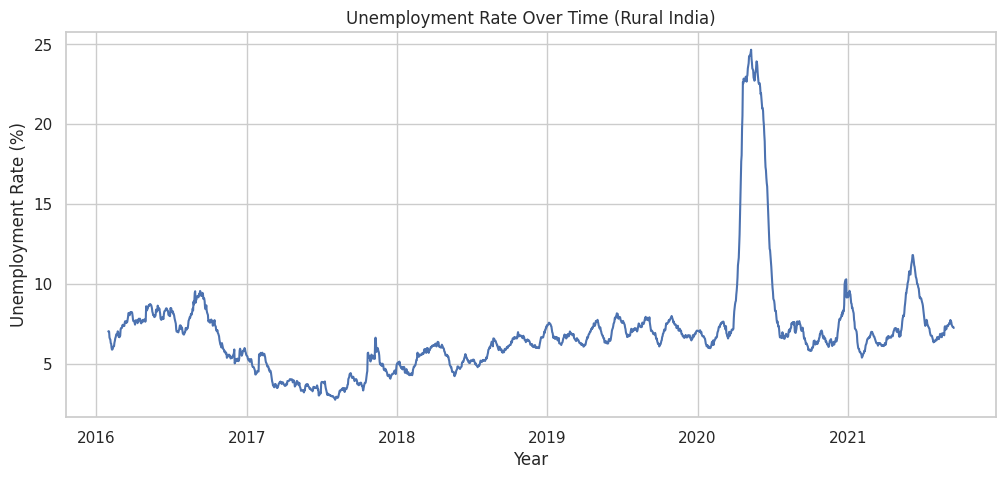

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Unemployment_Rate'])
plt.title('Unemployment Rate Over Time (Rural India)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.show()

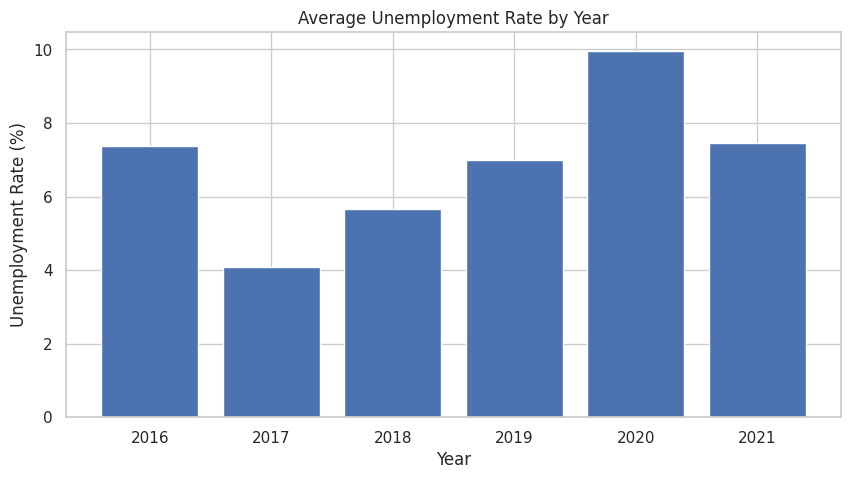

In [ ]:
yearly = df.groupby('Year')['Unemployment_Rate'].mean()

plt.figure(figsize=(10,5))
plt.bar(yearly.index, yearly.values)
plt.title('Average Unemployment Rate by Year')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.show()